In [88]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import pickle
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import ListedColormap
from matplotlib.ticker import AutoMinorLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

datadir  = '/home/mnedal/data/'
filename = 'OVSA/20260118.fits'

In [2]:
data = fits.open(f'{datadir}/{filename}')
data.info()

Filename: /home/mnedal/data//OVSA/20260118.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   (53385, 731, 1, 2)   float64   
  1  SFREQ         1 BinTableHDU     11   731R x 1C   [E]   
  2  UT            1 BinTableHDU     13   53385R x 2C   [J, J]   
  3  FREQ_CAL      1 BinTableHDU     15   3072R x 3C   [E, E, E]   


In [3]:
data[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    4 / number of array dimensions                     
NAXIS1  =                53385                                                  
NAXIS2  =                  731                                                  
NAXIS3  =                    1                                                  
NAXIS4  =                    2                                                  
EXTEND  =                    T                                                  
FILENAME= '20260118.fits'                                                       
ORIGIN  = 'NJIT    '           / Location where file was made                   
DATE    = '2026-01-19T12:06:06.605' / Date when file was made                   
OBSERVER= 'EOVSA Team'         / Who to appreciate/blame                        
TELESCOP= 'EOVSA   '        

In [4]:
st = data[0].header['DATE_OBS']
et = data[0].header['DATE_END']
st = st.replace('T', ' ').split('.')[0]
et = et.replace('T', ' ').split('.')[0]

In [5]:
spec = data[0].data
spec.shape

(2, 1, 731, 53385)

In [6]:
spec = spec[:, 0, :, :]
spec.shape

(2, 731, 53385)

In [7]:
spec_pol = spec[0]
spec_pol.shape

(731, 53385)

In [8]:
freq = data['SFREQ'].data['SFREQ']
freq.shape

(731,)

In [9]:
ut = data['UT'].data
mjd  = ut['mjd']
ms   = ut['time']
time_mjd = mjd + ms / 86400000.0

In [10]:
time_mjd

array([61058.67361441, 61058.67362036, 61058.67362631, ...,
       61058.99651073, 61058.99651668, 61058.99652262])

In [11]:
from astropy.time import Time

t = Time(time_mjd, format='mjd')
time_dt = t.to_datetime()
time_dt

array([datetime.datetime(2026, 1, 18, 16, 10, 0, 285000),
       datetime.datetime(2026, 1, 18, 16, 10, 0, 799000),
       datetime.datetime(2026, 1, 18, 16, 10, 1, 313000), ...,
       datetime.datetime(2026, 1, 18, 23, 54, 58, 527000),
       datetime.datetime(2026, 1, 18, 23, 54, 59, 41000),
       datetime.datetime(2026, 1, 18, 23, 54, 59, 554000)], dtype=object)

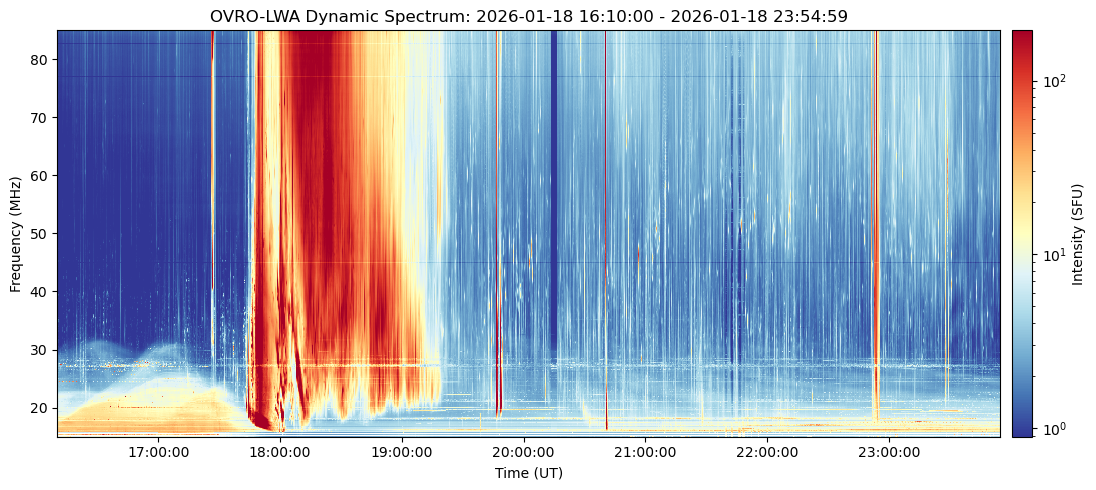

In [12]:
fig = plt.figure(figsize=[12,5])
ax  = fig.add_subplot(111)
dyspec = ax.pcolormesh(
    time_dt,
    freq*1e3,
    # np.log10(spec_pol),
    spec_pol,
    norm=LogNorm(vmin=np.nanpercentile(spec_pol, 5),
                 vmax=np.nanpercentile(spec_pol, 99)),
    cmap='RdYlBu_r'
)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title(f'OVRO-LWA Dynamic Spectrum: {st} - {et}')
plt.colorbar(dyspec, pad=0.01, label='Intensity (SFU)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.tight_layout()
plt.show()

In [13]:
from datetime import datetime
from typing import Union, List, Tuple

def find_nearest_datetime(times: Union[List, np.ndarray], target: Union[str, datetime]) -> Tuple[int, datetime]:
    """
    Find the index and value of the datetime nearest to target.

    Parameters
    ----------
    times : list or np.ndarray
        List or array of datetime objects or ISO-format strings.
    target : str or datetime
        Target datetime (string in ISO format or datetime object).

    Returns
    -------
    nearest_idx : int
        Index of the nearest datetime in the array.
    nearest_time : datetime
        The nearest datetime object from the array.
    """
    # Convert target to datetime if string
    if isinstance(target, str):
        target_dt = datetime.fromisoformat(target)
    else:
        target_dt = target

    # Convert times to datetime objects if they are strings
    if isinstance(times[0], str):
        times_dt = [datetime.fromisoformat(t) for t in times]
    else:
        times_dt = times

    # Compute absolute differences in seconds
    differences = [abs((t - target_dt).total_seconds()) for t in times_dt]

    nearest_idx = differences.index(min(differences))
    return nearest_idx, times_dt[nearest_idx]

In [14]:
st_target = '2026-01-18T17:30:00'
et_target = '2026-01-18T19:30:00'

st_idx, st_nearest = find_nearest_datetime(time_dt, st_target)
et_idx, et_nearest = find_nearest_datetime(time_dt, et_target)

print(st_idx, st_nearest)
print(et_idx, et_nearest)

9228 2026-01-18 17:29:59.896000
23013 2026-01-18 19:30:00.210000


In [15]:
Time('2026-01-18 17:40:00', scale='utc', format='iso')

<Time object: scale='utc' format='iso' value=2026-01-18 17:40:00.000>

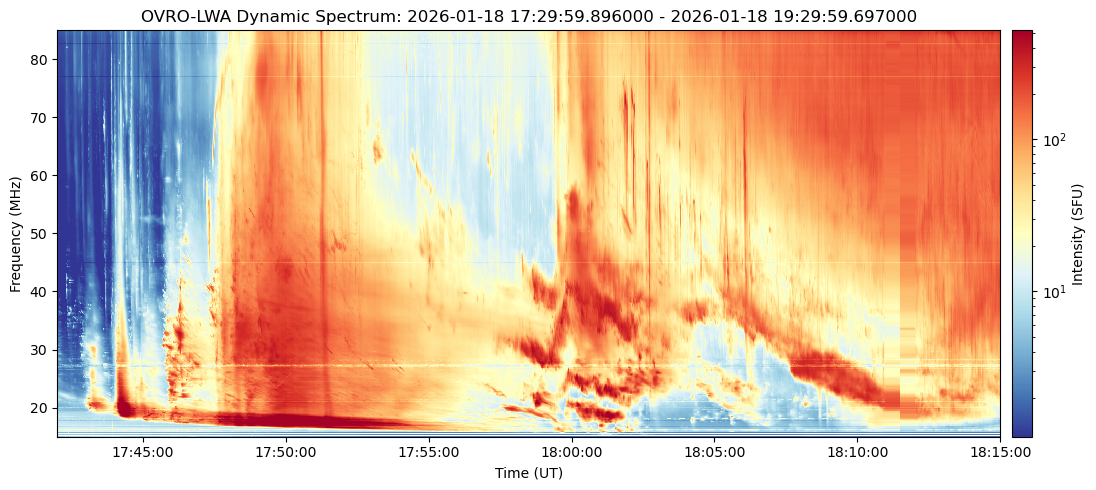

In [16]:
# slice the spectrum
sub_spec = spec_pol[:, st_idx:et_idx]
sub_time = time_dt[st_idx:et_idx]

fig = plt.figure(figsize=[12,5])
ax  = fig.add_subplot(111)
dyspec = ax.pcolormesh(
    sub_time,
    freq*1e3,
    sub_spec,
    norm=LogNorm(vmin=np.nanpercentile(sub_spec, 5),
                 vmax=np.nanpercentile(sub_spec, 99.9)),
    cmap='RdYlBu_r'
)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title(f'OVRO-LWA Dynamic Spectrum: {sub_time[0]} - {sub_time[-1]}')
plt.colorbar(dyspec, pad=0.01, label='Intensity (SFU)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
# ax.set_xlim(left=sub_time[0], right=sub_time[-1])
ax.set_xlim(left=Time('2026-01-18 17:42:00', scale='utc', format='iso').to_datetime(),
            right=Time('2026-01-18 18:15:00', scale='utc', format='iso').to_datetime()
           )
fig.tight_layout()
plt.show()

In [17]:
def find_nearest_frequency(freq_array: np.ndarray, target_freq: float) -> int:
    """
    Return the index of the frequency nearest to target_freq
    """
    idx = np.abs(freq_array - target_freq).argmin()
    return idx

In [18]:
# test a single freq
target_freq = 40

freq_idx = find_nearest_frequency(freq, target_freq/1e3)
print(f"Nearest frequency: {freq[freq_idx]*1e3} MHz (index {freq_idx})")

Nearest frequency: 40.015868842601776 MHz (index 261)


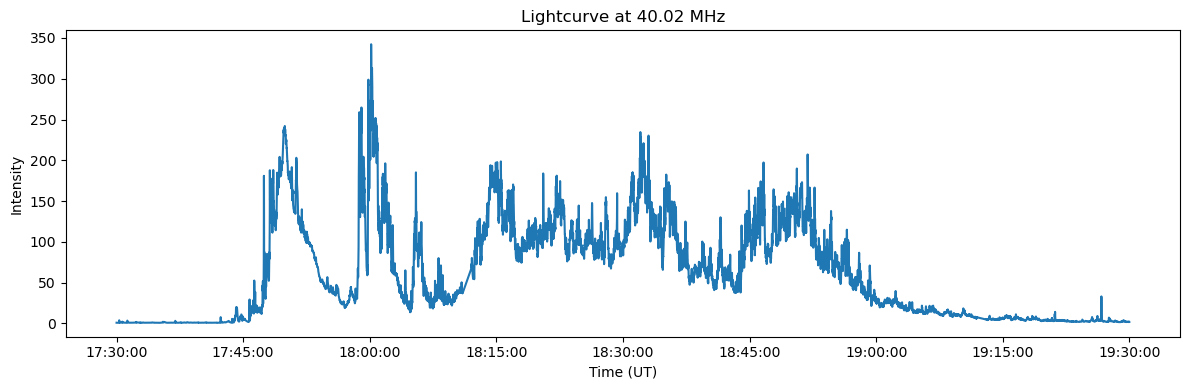

In [19]:
lightcurve = sub_spec[freq_idx, :]

fig = plt.figure(figsize=[12,4])
ax  = fig.add_subplot(111)
ax.plot(sub_time, lightcurve)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Intensity')
ax.set_title(f'Lightcurve at {freq[freq_idx]*1e3:.2f} MHz')
# ax.set_yscale('log')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.tight_layout()
plt.show()

In [20]:
# let's do several freqs
target_freqs = [20, 30, 40, 50, 60, 70, 80]
freq_indices = []
for target_freq in target_freqs:
    freq_idx = find_nearest_frequency(freq, target_freq/1e3)
    freq_indices.append(freq_idx)
    print(f"Nearest frequency: {freq[freq_idx]*1e3:.2f} MHz (index {freq_idx})")

Nearest frequency: 20.01 MHz (index 52)
Nearest frequency: 29.97 MHz (index 156)
Nearest frequency: 40.02 MHz (index 261)
Nearest frequency: 49.97 MHz (index 365)
Nearest frequency: 60.02 MHz (index 470)
Nearest frequency: 69.97 MHz (index 574)
Nearest frequency: 80.02 MHz (index 679)


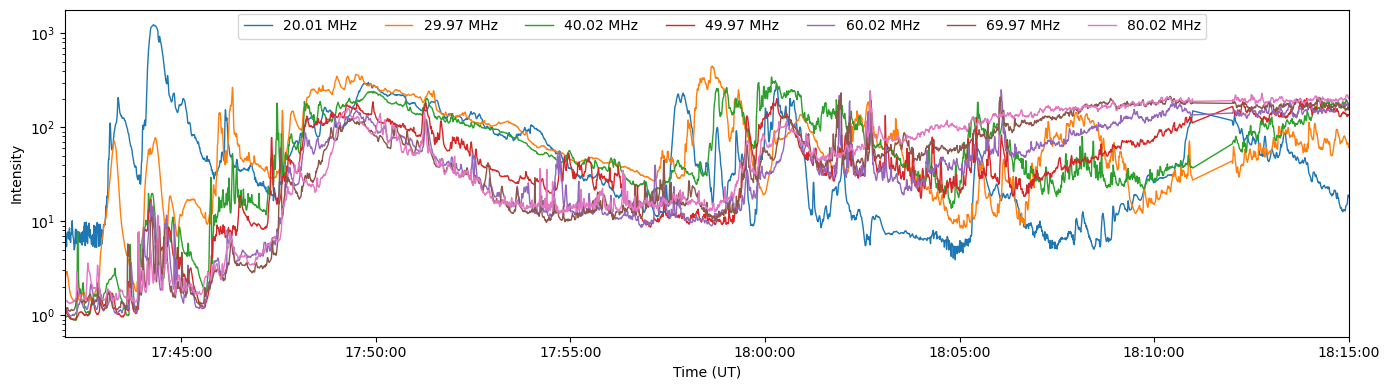

In [21]:
lwa_curves = {}
lwa_curves['time'] = sub_time

fig = plt.figure(figsize=[14,4])
ax  = fig.add_subplot(111)

for idx, f in zip(freq_indices, target_freqs):
    lightcurve = sub_spec[idx, :]
    label = f'{freq[idx]*1e3:.2f} MHz'
    ax.plot(sub_time, lightcurve, lw=1, label=label)    
    lwa_curves[label] = lightcurve

ax.set_xlabel('Time (UT)')
ax.set_ylabel('Intensity')
ax.set_yscale('log')
# ax.legend(bbox_to_anchor=(1.115,1.03))
ax.legend(ncol=len(target_freqs), bbox_to_anchor=(0.13,1.01))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
# ax.set_xlim(left=sub_time[0], right=sub_time[-1])
ax.set_xlim(left=Time('2026-01-18 17:42:00', scale='utc', format='iso').to_datetime(),
            right=Time('2026-01-18 18:15:00', scale='utc', format='iso').to_datetime()
           )
fig.tight_layout()
plt.show()

# save to file
with open(f"{datadir}/pkl_files/lwa_curves_{filename.split('/')[-1][:-5]}.pkl", 'wb') as f:
    pickle.dump(lwa_curves, f)

---

In [ ]:
# Detrend
# Empirical mode decomposition analysis

In [2]:
with open(f"{datadir}/pkl_files/lwa_curves_{filename.split('/')[-1][:-5]}.pkl", 'rb') as f:
    lwa_curves = pickle.load(f)

In [3]:
lwa_curves

{'time': array([datetime.datetime(2026, 1, 18, 17, 29, 59, 896000),
        datetime.datetime(2026, 1, 18, 17, 30, 0, 409000),
        datetime.datetime(2026, 1, 18, 17, 30, 0, 923000), ...,
        datetime.datetime(2026, 1, 18, 19, 29, 58, 670000),
        datetime.datetime(2026, 1, 18, 19, 29, 59, 183000),
        datetime.datetime(2026, 1, 18, 19, 29, 59, 697000)], dtype=object),
 '20.01 MHz': array([20.15628169, 19.22506941, 17.01801525, ..., 12.10139662,
        10.77318345, 11.86358126]),
 '29.97 MHz': array([1.34348831, 1.30309617, 1.29008299, ..., 2.60174279, 2.5811831 ,
        2.55086693]),
 '40.02 MHz': array([0.96072477, 0.92990474, 0.91509211, ..., 1.96232714, 1.98000648,
        1.96162176]),
 '49.97 MHz': array([0.95587763, 0.94407935, 0.94393971, ..., 1.7289778 , 1.74337032,
        1.75324475]),
 '60.02 MHz': array([0.98500922, 0.98794029, 0.98187693, ..., 1.87658612, 1.82965159,
        1.80795829]),
 '69.97 MHz': array([1.08646257, 1.08477262, 1.09859543, ..., 2.165


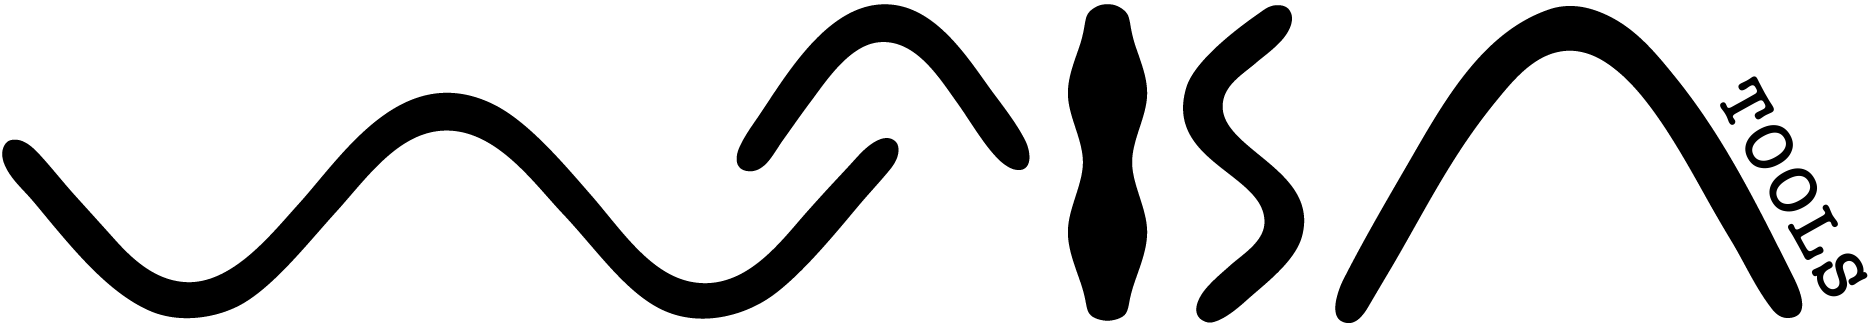

Dropdown(description='Category:', options=('Select Category', 'Single time series analysis', 'Cross-correlatio…

Dropdown(description='Data Type:', options=('Select Data Type',), value='Select Data Type')

Dropdown(description='Method:', options=('Select Method',), value='Select Method')

Dropdown(description='Sub-method:', layout=Layout(display='none'), options=('Select Sub-method', 'FFT', 'Wavel…

Output()

In [4]:
# switch to walsa env
from WaLSAtools import WaLSAtools
WaLSAtools

In [5]:
lwa_curves.keys()

dict_keys(['time', '20.01 MHz', '29.97 MHz', '40.02 MHz', '49.97 MHz', '60.02 MHz', '69.97 MHz', '80.02 MHz'])

In [7]:
channel = '29.97 MHz'
signal  = lwa_curves[channel]
time_dt = lwa_curves['time']
time    = [mdates.date2num(t) for t in time_dt]

In [ ]:
# EMD & HHT Calculations using WaLSAtools
HHT_power_spectrum, HHT_significance_level, HHT_freq_bins, psd_spectra_fft, confidence_levels_fft, imfs, IMF_significance_levels, instantaneous_frequencies = WaLSAtools(
    signal=signal,
    time=time,
    method='emd',
    siglevel=0.95
)

In [ ]:
fig = plt.figure(figsize=[14,4])
ax  = fig.add_subplot(111)
ax.plot(time, signal, lw=1, label=channel)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Intensity')
ax.set_yscale('log')
ax.legend()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.set_xlim(left=time[0], right=time[-1])
fig.tight_layout()
plt.show()

In [49]:
# save EMD outputs
base = os.path.abspath('.')
outdir = os.path.join(base, 'QPPs_20260118', 'EMD')
os.makedirs(outdir, exist_ok=True)

with open(f'{outdir}/HHT_power_spectrum_{channel}.pkl', 'wb') as f:
    pickle.dump(HHT_power_spectrum, f)
with open(f'{outdir}/HHT_significance_level_{channel}.pkl', 'wb') as f:
    pickle.dump(HHT_significance_level, f)
with open(f'{outdir}/HHT_freq_bins_{channel}.pkl', 'wb') as f:
    pickle.dump(HHT_freq_bins, f)
with open(f'{outdir}/psd_spectra_fft_{channel}.pkl', 'wb') as f:
    pickle.dump(psd_spectra_fft, f)
with open(f'{outdir}/confidence_levels_fft_{channel}.pkl', 'wb') as f:
    pickle.dump(confidence_levels_fft, f)
with open(f'{outdir}/imfs_{channel}.pkl', 'wb') as f:
    pickle.dump(imfs, f)
with open(f'{outdir}/IMF_significance_levels_{channel}.pkl', 'wb') as f:
    pickle.dump(IMF_significance_levels, f)
with open(f'{outdir}/instantaneous_frequencies_{channel}.pkl', 'wb') as f:
    pickle.dump(instantaneous_frequencies, f)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import AutoMinorLocator
# import matplotlib.gridspec as gridspec

# # def custom_round(freq):
# #     if freq < 1:
# #         return round(freq, 1)
# #     else:
# #         return round(freq)

# # Setting global parameters
# plt.rcParams.update({
#     'font.size': 12,          # Global font size
#     'axes.titlesize': 11,     # Title font size
#     'axes.labelsize': 11,     # Axis label font size
#     'xtick.labelsize': 10,    # X-axis tick label font size
#     'ytick.labelsize': 10,    # Y-axis tick label font size
#     'legend.fontsize': 12,    # Legend font size
#     'figure.titlesize': 12.5,   # Figure title font size
#     'axes.grid': False,        # Turn on grid by default
#     'grid.alpha': 0.5,        # Grid transparency
#     'grid.linestyle': '--',   # Grid line style
# })

# # significance_threshold = 0.05

# # plt.rc('axes', linewidth=1.0)
# # plt.rc('lines', linewidth=1.3)

# # Color cycle for consistency across plots
# colors = plt.cm.tab10(np.linspace(0, 1, len(imfs)))

# # Create a multi-panel plot with custom grid layout
# fig = plt.figure(figsize=[14,18], constrained_layout=True)
# gs = gridspec.GridSpec(len(imfs) + 2, 2, height_ratios=[1]*len(imfs) + [0.3, 2], figure=fig)

# # Plot each IMF and its instantaneous frequency side by side
# for i, (imf, freq) in enumerate(zip(imfs, instantaneous_frequencies)):
#     ax_imf = fig.add_subplot(gs[i, 0])
#     ax_if = fig.add_subplot(gs[i, 1])

#     # if IMF_significance_levels[i] > significance_threshold:
#     #     ax_imf.set_facecolor('lightgray')
#     ax_imf.plot(time, imf, label=f'IMF {i+1}', color=colors[i])
#     ax_imf.set_ylabel(f'IMF {i+1}')
#     ax_imf.xaxis_date()
#     ax_imf.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
#     ax_imf.set_xlim(left=time[0], right=time[-1])
#     # ax_imf.yaxis.set_label_coords(-0.16, 0.5)  # Align y-axis labels
#     # ax_imf.xaxis.set_minor_locator(AutoMinorLocator(5))
#     # ax_imf.yaxis.set_minor_locator(AutoMinorLocator(3))
#     # ax_imf.tick_params(axis='both', which='major', direction='in', length=6, width=1.0)
#     # ax_imf.tick_params(axis='both', which='minor', direction='in', length=3, width=1.0)
#     if i < len(imfs) - 1:
#         ax_imf.set_xticklabels([])  # Hide x labels for all but the last IMF plot
#     if i == 0:
#         ax_imf.set_title('(a) IMFs')
#         # ax_imf.tick_params(axis='x', which='both', top=False)  # Turn off upper x-axis ticks
#     # ax_imf.set_xlim(0, 10)
#     if i == len(imfs) - 1:
#         ax_imf.set_xlabel('Time (s)')

#     # if IMF_significance_levels[i] > significance_threshold:
#     #     ax_if.set_facecolor('lightgray')
#     if len(freq) < len(time):
#         freq = np.append(freq, freq[-1])  # Extend freq to match the length of time

#     ax_if.plot(time, freq, label=f'IF {i+1}', color=colors[i])
#     ax_if.set_ylabel(f'IF {i+1} (Hz)')
#     ax_if.set_yscale('log')
#     ax_if.xaxis_date()
#     ax_if.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
#     ax_if.set_xlim(left=time[0], right=time[-1])
#     # ax_if.yaxis.set_label_coords(-0.1, 0.5)  # Align y-axis labels
#     # ax_if.xaxis.set_minor_locator(AutoMinorLocator(5))
#     # ax_if.yaxis.set_minor_locator(AutoMinorLocator(5))
#     # ax_if.tick_params(axis='both', which='major', direction='in', length=6, width=1.0)
#     # ax_if.tick_params(axis='both', which='minor', direction='in', length=3, width=1.0)
#     if i < len(imfs) - 1:
#         ax_if.set_xticklabels([])  # Hide x labels for all but the last IF plot
#     if i == 0:
#         ax_if.set_title('(b) Instantaneous Frequencies')
#         # ax_if.tick_params(axis='x', which='both', top=False)  # Turn off upper x-axis ticks
#     # ax_if.set_xlim(0, 10)
#     if i == len(imfs) - 1:
#         ax_if.set_xlabel('Time (s)')

# # Plot the HHT marginal spectrum and FFT spectra in the last row
# # Panel (c): HHT Marginal Spectrum
# ax_hht = fig.add_subplot(gs[-1, 0])
# # freq_bins = np.linspace(0, 50, len(HHT_power_spectrum))  # Assuming a maximum frequency of 50 Hz for illustration
# ax_hht.plot(HHT_freq_bins, HHT_power_spectrum, color='black')
# ax_hht.plot(HHT_freq_bins, HHT_significance_level, linestyle='--', color='green')
# ax_hht.set_title('(c) HHT Marginal Spectrum')
# ax_hht.set_xlabel('Frequency (Hz)')
# ax_hht.set_ylabel('Power')
# ax_hht.set_xscale('log')
# ax_hht.set_yscale('log')
# # ax_hht.xaxis.set_minor_locator(AutoMinorLocator(5))
# # ax_hht.yaxis.set_minor_locator(AutoMinorLocator(5))
# # ax_hht.tick_params(axis='both', which='major', direction='out', length=6, width=1.0)
# # ax_hht.tick_params(axis='both', which='minor', direction='out', length=3, width=1.0)
# ax_hht.tick_params(axis='x', which='both', top=False)  # Turn off upper x-axis ticks
# # ax_hht.set_xlim(0,36)
# # ax_hht.set_ylim(bottom=0)
# # # Mark pre-defined frequencies with vertical lines
# # pre_defined_freq = [2,5,10,12,15,18,25,33]
# # for freq in pre_defined_freq:
# #     rounded_freq = custom_round(freq)
# #     plt.axvline(x=freq, color='gray', linestyle=':')

# # Panel (d): FFT Spectra of IMFs
# ax_fft = fig.add_subplot(gs[-1, 1])
# for i, (xf, psd) in enumerate(psd_spectra_fft):
#     ax_fft.plot(xf, psd, label=f'IMF {i+1}', color=colors[i])
# for i, confidence_level in enumerate(confidence_levels_fft):
#     ax_fft.plot(xf, confidence_level, linestyle='--', color=colors[i])
# ax_fft.set_title('(d) FFT Spectra of IMFs')
# ax_fft.set_xlabel('Frequency (Hz)')
# ax_fft.set_ylabel('Power')
# ax_fft.set_xscale('log')
# ax_fft.set_yscale('log')
# # ax_fft.xaxis.set_minor_locator(AutoMinorLocator(5))
# # ax_fft.yaxis.set_minor_locator(AutoMinorLocator(5))
# # ax_fft.tick_params(axis='both', which='major', direction='out', length=6, width=1.0)
# # ax_fft.tick_params(axis='both', which='minor', direction='out', length=3, width=1.0)
# ax_fft.tick_params(axis='x', which='both', top=False)  # Turn off upper x-axis ticks
# # ax_fft.set_xlim(0,36)
# # ax_fft.set_ylim(0,2.5)
# # # Mark pre-defined frequencies with vertical lines
# # pre_defined_freq = [2,5,10,12,15,18,25,33]
# # for freq in pre_defined_freq:
# #     rounded_freq = custom_round(freq)
# #     plt.axvline(x=freq, color='gray', linestyle=':')

# # Save the figure as a PDF
# # pdf_path = 'Figures/FigS2_EMD_analysis.pdf'
# # WaLSA_save_pdf(fig, pdf_path, color_mode='CMYK', dpi=300, bbox_inches='tight', pad_inches=0)

# plt.show()

In [ ]:
# Global plot settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'figure.titlesize': 12.5,
    'axes.grid': False,
})

colors = plt.cm.tab10(np.linspace(0, 1, len(imfs)))
n_imf = len(imfs)

# Figure + GridSpec
fig = plt.figure(figsize=[10, 20], constrained_layout=True)
gs = gridspec.GridSpec(
    n_imf + 3, 2,
    height_ratios=[1.2] + [1]*n_imf + [0.3, 2],
    figure=fig
)

# -------------------------------------------------
# Top panel: original signal
# -------------------------------------------------
ax_sig = fig.add_subplot(gs[0, :])
ax_sig.plot(time, signal, lw=1, label=channel)
ax_sig.set_ylabel('Intensity')
ax_sig.set_yscale('log')
ax_sig.legend()
ax_sig.xaxis_date()
ax_sig.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_sig.set_xlim(time[0], time[-1])
ax_sig.set_title('(a) Lightcurve')

# -------------------------------------------------
# IMF + Instantaneous frequency panels
# -------------------------------------------------
for i, (imf, freq) in enumerate(zip(imfs, instantaneous_frequencies)):
    ax_imf = fig.add_subplot(gs[i + 1, 0])
    ax_if  = fig.add_subplot(gs[i + 1, 1])

    ax_imf.plot(time, imf, color=colors[i], label=f'IMF {i+1}')
    ax_imf.set_ylabel(f'IMF {i+1}')
    ax_imf.xaxis_date()
    ax_imf.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax_imf.set_xlim(time[0], time[-1])
    if i < n_imf - 1:
        ax_imf.set_xticklabels([])
    if i == 0:
        ax_imf.set_title('(b) IMFs')
    if i == n_imf - 1:
        ax_imf.set_xlabel('Time (UT)')

    if len(freq) < len(time):
        freq = np.append(freq, freq[-1])

    ax_if.plot(time, freq, color=colors[i], label=f'IF {i+1}')
    ax_if.set_ylabel(f'IF {i+1} (Hz)')
    ax_if.set_yscale('log')
    ax_if.xaxis_date()
    ax_if.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax_if.set_xlim(time[0], time[-1])
    if i < n_imf - 1:
        ax_if.set_xticklabels([])
    if i == 0:
        ax_if.set_title('(c) Instantaneous Frequencies')
    if i == n_imf - 1:
        ax_if.set_xlabel('Time (UT)')

# -------------------------------------------------
# Bottom row: HHT + FFT
# -------------------------------------------------
ax_hht = fig.add_subplot(gs[-1, 0])
ax_hht.plot(HHT_freq_bins, HHT_power_spectrum, color='black')
ax_hht.plot(HHT_freq_bins, HHT_significance_level, '--', color='green')
ax_hht.set_title('(d) HHT Marginal Spectrum')
ax_hht.set_xlabel('Frequency (Hz)')
ax_hht.set_ylabel('Power')
ax_hht.set_xscale('log')
ax_hht.set_yscale('log')

ax_fft = fig.add_subplot(gs[-1, 1])
for i, (xf, psd) in enumerate(psd_spectra_fft):
    ax_fft.plot(xf, psd, color=colors[i], label=f'IMF {i+1}')
for i, confidence_level in enumerate(confidence_levels_fft):
    ax_fft.plot(xf, confidence_level, '--', color=colors[i])

ax_fft.set_title('(e) FFT Spectra of IMFs')
ax_fft.set_xlabel('Frequency (Hz)')
ax_fft.set_ylabel('Power')
ax_fft.set_xscale('log')
ax_fft.set_yscale('log')

plt.show()

---

In [8]:
import numpy as np
from WaLSAtools import WaLSAtools, walsa_detrend_apod
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

#--------------------------------------------------------------------------
# FFT Analysis using WaLSAtools
fft_power, fft_freqs, fft_significance = WaLSAtools(signal=signal, time=time, method='fft', siglevel=0.95, apod=0.1)
# Normalize FFT power to its maximum value
fft_power_normalized = 100 * fft_power / np.max(fft_power)
fft_significance_normalized = 100 * fft_significance / np.max(fft_power)
#--------------------------------------------------------------------------
# Lomb-Scargle Analysis using WaLSAtools
ls_power, ls_freqs, ls_significance = WaLSAtools(signal=signal, time=time, method='lombscargle', siglevel=0.95, apod=0.1)
# Normalize Lomb-Scargle power to its maximum value
ls_power_normalized = 100 * ls_power / np.max(ls_power)
ls_significance_normalized = 100 * ls_significance / np.max(ls_power)
#--------------------------------------------------------------------------
# Wavelet Analysis using WaLSAtools - Morlet
wavelet_power_morlet, wavelet_periods_morlet, wavelet_significance_morlet, coi_morlet, (global_power_morlet, global_conf_morlet), (rgws_morlet_periods, rgws_morlet_power) = WaLSAtools(
    signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='morlet', GWS=True, RGWS=True
)
#--------------------------------------------------------------------------
# Wavelet Analysis using WaLSAtools - DOG (Mexican Hat)
wavelet_power_dog, wavelet_periods_dog, wavelet_significance_dog, coi_dog, (global_power_dog, global_conf_dog), (rgws_dog_periods, rgws_dog_power) = WaLSAtools(
    signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='dog', GWS=True, RGWS=True
)
#--------------------------------------------------------------------------
# Wavelet Analysis using WaLSAtools - Paul
wavelet_power_paul, wavelet_periods_paul, wavelet_significance_paul, coi_paul, (global_power_paul, global_conf_paul), (rgws_paul_periods, rgws_paul_power) = WaLSAtools(
    signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='paul', GWS=True, RGWS=True
)
#--------------------------------------------------------------------------
# Welch Power Spectral Density Analysis using WaLSAtools
welch_psd, welch_freqs, welch_significance = WaLSAtools(signal=signal, time=time, method='welch', siglevel=0.95, nperseg=200, noverlap=20)
# Normalize Welch PSD to its maximum value
welch_psd_normalized = 100 * welch_psd / np.max(welch_psd)
welch_significance_normalized = 100 * welch_significance / np.max(welch_psd)
#--------------------------------------------------------------------------
# EMD & HHT Calculations using WaLSAtools
HHT_power_spectrum_EMD, HHT_significance_level_EMD, HHT_freq_bins_EMD, psd_spectra_fft_EMD, confidence_levels_fft_EMD, _, _, _ = WaLSAtools(
    signal=signal, time=time, method='emd', siglevel=0.95)
# Normalize power spectra to their maximum values
HHT_power_spectrum_EMD_normalized = 100 * HHT_power_spectrum_EMD / np.max(HHT_power_spectrum_EMD)
HHT_significance_level_EMD_normalized = 100 * HHT_significance_level_EMD / np.max(HHT_power_spectrum_EMD)
#--------------------------------------------------------------------------
# EEMD & HHT Calculations using WaLSAtools
HHT_power_spectrum_EEMD, HHT_significance_level_EEMD, HHT_freq_bins_EEMD, psd_spectra_fft_EEMD, confidence_levels_fft_EEMD, _, _, _ = WaLSAtools(
    signal=signal, time=time, method='emd', siglevel=0.95, EEMD=True)
# Normalize power spectra to their maximum values
HHT_power_spectrum_EEMD_normalized = 100 * HHT_power_spectrum_EEMD / np.max(HHT_power_spectrum_EEMD)
HHT_significance_level_EEMD_normalized = 100 * HHT_significance_level_EEMD / np.max(HHT_power_spectrum_EEMD)

ImportError: cannot import name 'walsa_detrend_apod' from 'WaLSAtools' (/mnt/mnedal_data/anaconda3/envs/walsa/lib/python3.12/site-packages/WaLSAtools/__init__.py)

In [8]:
# Wavelet Analysis using WaLSAtools
power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(signal=signal, time=time, method='wavelet')

Detrending and apodization complete.
Wavelet (morlet) processed.


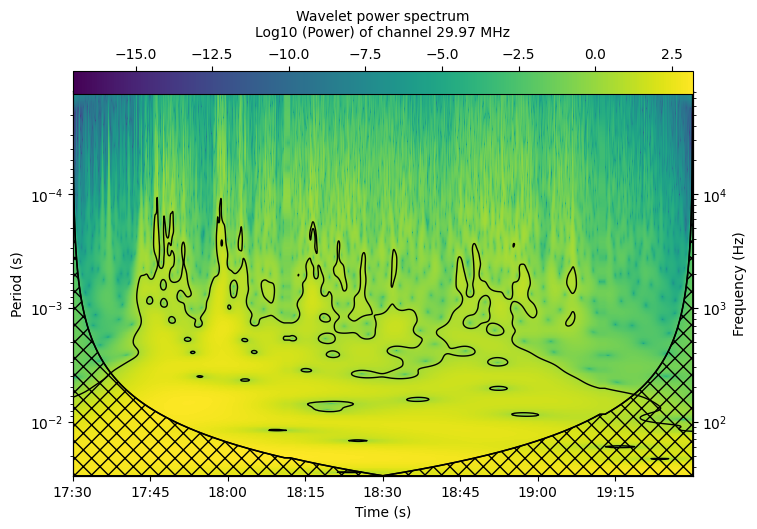

In [41]:
# Plot Wavelet power spectrum
fig = plt.figure(figsize=[8,5])
ax  = fig.add_subplot(111)

colorbar_label = f'Wavelet power spectrum\nLog10 (Power) of channel {channel}'
ylabel = 'Period (s)'
xlabel = 'Time (s)'
cmap = 'viridis' # jet, RdYlBu_r, plasma, viridis

tdiff = np.diff(time)
cadence = np.median(tdiff)

# Apply log10 transformation to the power and avoid negative or zero values
power[power <= 0] = np.nan  # Avoid log10 of zero or negative values
log_power = np.log10(power)  # Calculate log10 of the power
periods = period

t = np.array(time)
sig_slevel = significance
dt = cadence

# Optional: Remove large periods outside the cone of influence (if enabled)
removespace = True
if removespace:
    max_period = np.max(coi)
    cutoff_index = np.argmax(periods > max_period)

    # Ensure cutoff_index is within bounds
    if cutoff_index > 0 and cutoff_index <= len(periods):
        log_power = log_power[:cutoff_index, :]
        periods = periods[:cutoff_index]
        sig_slevel = sig_slevel[:cutoff_index, :]

# Define levels for log10 color scaling (adjust to reflect log10 range)
min_log_power = np.nanmin(log_power)
max_log_power = np.nanmax(log_power)
levels = np.linspace(min_log_power, max_log_power, 100)  # Color levels for log10 scale

# Plot the wavelet power spectrum using log10(power)
# CS = ax_inset_g.contourf(t, periods, log_power, levels=levels, cmap=cmap, extend='neither')
CS = ax.pcolormesh(t, periods, log_power, vmin=min_log_power, vmax=max_log_power, cmap=cmap, shading='auto')

# 95% significance contour (significance levels remain the same)
ax.contour(t, periods, sig_slevel, levels=[1], colors='k', linewidths=[1.0])

# Cone-of-influence (COI)
ax.plot(t, coi, '-k', lw=1.15)
ax.fill(
    np.concatenate([t, t[-1:] + dt, t[-1:] + dt, t[:1] - dt, t[:1] - dt]),
    np.concatenate([coi, [1e-9], [np.max(periods)], [np.max(periods)], [1e-9]]),
    color='none', edgecolor='k', alpha=1, hatch='xx'
)

# Log scale for periods
ax.set_ylim([np.min(periods), np.max(periods)])
# ax.set_yscale('log', base=10)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.invert_yaxis()
ax.set_yscale('log')

# Set axis limits and labels
ax.set_xlim([t.min(), t.max()])
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel)
# ax.tick_params(axis='both', which='both', direction='out', length=8, width=1.5, top=True, right=True
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Custom tick intervals
# ax.set_xticks(np.arange(0, 10, 2))

# Custom tick sizes and thickness
# ax.tick_params(axis='both', which='major', length=8, width=1.5, right=True)  # Major ticks
# ax.tick_params(axis='both', which='minor', top=True, right=True, length=4, width=1.5)

# Set the number of minor ticks (e.g., 4 minor ticks between major ticks)
# ax.xaxis.set_minor_locator(AutoMinorLocator(4))

# Add a secondary y-axis for frequency in Hz
ax_freq = ax.twinx()
min_frequency = 1 / np.max(periods)
max_frequency = 1 / np.min(periods)
# ax_freq.set_yscale('log', base=10)
ax_freq.set_ylim([max_frequency, min_frequency])  # Adjust frequency range properly
ax_freq.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax_freq.invert_yaxis()
ax_freq.set_ylabel('Frequency (Hz)')
ax_freq.set_yscale('log')
# ax_freq.tick_params(axis='both', which='major', length=8, width=1.5)
# ax_freq.tick_params(axis='both', which='minor', top=True, right=True, length=4, width=1.5)

# Create an inset color bar axis above the plot with a slightly reduced width
divider = make_axes_locatable(ax)
cax = inset_axes(ax, width="100%", height="6%", loc='upper center', borderpad=-1.4)
cbar = plt.colorbar(CS, cax=cax, orientation='horizontal')

# Move color bar label to the top of the bar
cbar.set_label(colorbar_label, labelpad=8)
cbar.ax.tick_params(direction='out', top=True, labeltop=True, bottom=False, labelbottom=False)
cbar.ax.xaxis.set_label_position('top')

# Adjust tick marks for the color bar
# cbar.ax.tick_params(axis='x', which='major', length=6, width=1.2, direction='out', top=True, labeltop=True, bottom=False)
# cbar.ax.tick_params(axis='x', which='minor', length=3, width=1.0, direction='out', top=True, bottom=False)

# Set custom tick locations for colorbar
# custom_ticks = [0, -2, -4, -6]  # Specify tick positions (must be within log10(power) range)
# cbar.set_ticks(custom_ticks)
# cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))

# Set minor ticks on the colorbar
# cbar.ax.xaxis.set_minor_locator(AutoMinorLocator(4))

plt.show()

---

In [128]:
# load STIX QL data
energy_labels = [
    '4 – 10 keV',
    '10 – 15 keV',
    '15 – 25 keV',
    '25 – 50 keV',
    '50 – 84 keV'
]
start_time = '2026-01-18T17:35:00'
end_time   = '2026-01-18T18:15:00'

label = '50 – 84 keV'

with open(f'/home/mnedal/repos/dias_work/QPPs_20260118/STIX/ql_lc_{label}.pkl', 'rb') as f:
    set = pickle.load(f)
times, signal = set
signal = signal.value
time = [mdates.date2num(t) for t in times]

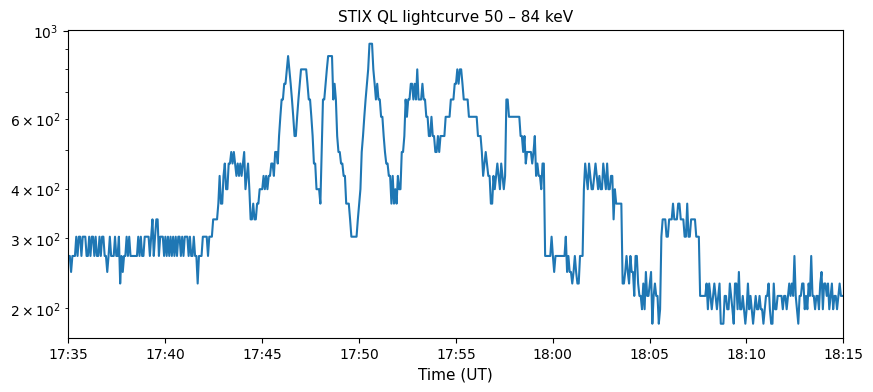

In [129]:
fig = plt.figure(figsize=[10,4])
ax  = fig.add_subplot(111)
ax.plot(time, signal)
ax.set_title(f'STIX QL lightcurve {label}')
ax.set_xlabel('Time (UT)')
ax.semilogy()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlim(pd.Timestamp(start_time), pd.Timestamp(end_time))
plt.show()

In [151]:
# Wavelet Analysis using WaLSAtools
mother_func = 'default1' # default2=morlet, dog (Mexican Hat), paul

if mother_func=='default1':
    power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(signal=signal, time=time, method='wavelet')
elif mother_func=='default2':
    power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(
    signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, GWS=True, RGWS=True)
elif mother_func=='morlet':
    power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(
        signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='morlet', GWS=True, RGWS=True)
elif mother_func=='dog':
    power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(
        signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='dog', GWS=True, RGWS=True)
elif mother_func=='paul':
    power, period, significance, coi, gws_power, gws_significance, rgws_power = WaLSAtools(
        signal=signal, time=time, method='wavelet', siglevel=0.95, apod=0.1, mother='paul', GWS=True, RGWS=True)
else:
    print('Wrong mother function!')

Detrending and apodization complete.
Wavelet (morlet) processed.


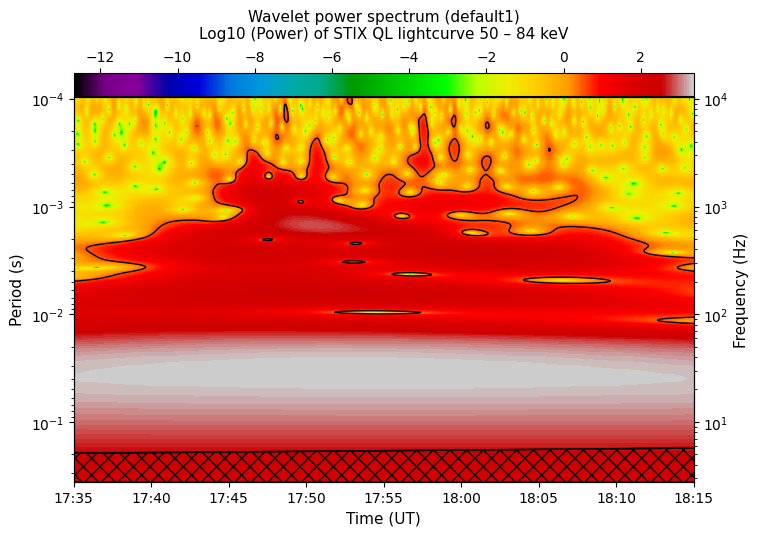

In [153]:
# Plot Wavelet power spectrum
fig = plt.figure(figsize=[8,5])
ax  = fig.add_subplot(111)

colorbar_label = f'Wavelet power spectrum ({mother_func})\nLog10 (Power) of STIX QL lightcurve {label}'
ylabel = 'Period (s)'
xlabel = 'Time (UT)'
cmap = 'nipy_spectral' # jet, rainbow, nipy_spectral, RdYlBu_r, plasma, viridis

tdiff = np.diff(time)
cadence = np.median(tdiff)

# Apply log10 transformation to the power and avoid negative or zero values
power[power <= 0] = np.nan  # Avoid log10 of zero or negative values
log_power = np.log10(power)  # Calculate log10 of the power
periods = period

t = np.array(time)
sig_slevel = significance
dt = cadence

# Optional: Remove large periods outside the cone of influence (if enabled)
removespace = True
if removespace:
    max_period = np.max(coi)
    cutoff_index = np.argmax(periods > max_period)

    # Ensure cutoff_index is within bounds
    if cutoff_index > 0 and cutoff_index <= len(periods):
        log_power = log_power[:cutoff_index, :]
        periods = periods[:cutoff_index]
        sig_slevel = sig_slevel[:cutoff_index, :]

# Define levels for log10 color scaling (adjust to reflect log10 range)
min_log_power = np.nanmin(log_power)
max_log_power = np.nanmax(log_power)
levels = np.linspace(min_log_power, max_log_power, 100)  # Color levels for log10 scale

# Plot the wavelet power spectrum using log10(power)
# CS = ax.contourf(t, periods, log_power, levels=levels, cmap=cmap, extend='neither')
CS = ax.pcolormesh(t, periods, log_power, vmin=min_log_power, vmax=max_log_power, cmap=cmap, shading='auto')

# 95% significance contour (significance levels remain the same)
ax.contour(t, periods, sig_slevel, levels=[1], colors='k', linewidths=[1.0])

# Cone-of-influence (COI)
ax.plot(t, coi, '-k', lw=1.15)
ax.fill(
    np.concatenate([t, t[-1:] + dt, t[-1:] + dt, t[:1] - dt, t[:1] - dt]),
    np.concatenate([coi, [1e-9], [np.max(periods)], [np.max(periods)], [1e-9]]),
    color='none', edgecolor='k', alpha=1, hatch='xx'
)

# Log scale for periods
ax.set_ylim([np.min(periods), np.max(periods)])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.invert_yaxis()
ax.set_yscale('log')

# Set axis limits and labels
ax.set_xlim([t.min(), t.max()])
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlim(pd.Timestamp(start_time), pd.Timestamp(end_time))

# Add a secondary y-axis for frequency in Hz
ax_freq = ax.twinx()
min_frequency = 1 / np.max(periods)
max_frequency = 1 / np.min(periods)
# ax_freq.set_yscale('log', base=10)
ax_freq.set_ylim([max_frequency, min_frequency])  # Adjust frequency range properly
ax_freq.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax_freq.invert_yaxis()
ax_freq.set_ylabel('Frequency (Hz)')
ax_freq.set_yscale('log')

# Create an inset color bar axis above the plot with a slightly reduced width
divider = make_axes_locatable(ax)
cax = inset_axes(ax, width="100%", height="6%", loc='upper center', borderpad=-1.4)
cbar = plt.colorbar(CS, cax=cax, orientation='horizontal')

# Move color bar label to the top of the bar
cbar.set_label(colorbar_label, labelpad=8)
cbar.ax.tick_params(direction='out', top=True, labeltop=True, bottom=False, labelbottom=False)
cbar.ax.xaxis.set_label_position('top')

plt.show()

In [107]:
# EMD & HHT Calculations using WaLSAtools
HHT_power_spectrum, HHT_significance_level, HHT_freq_bins, psd_spectra_fft, confidence_levels_fft, imfs, IMF_significance_levels, instantaneous_frequencies = WaLSAtools(
    signal=signal,
    time=time,
    method='emd',
    siglevel=0.95
)

Detrending and apodization complete.
EMD processed.


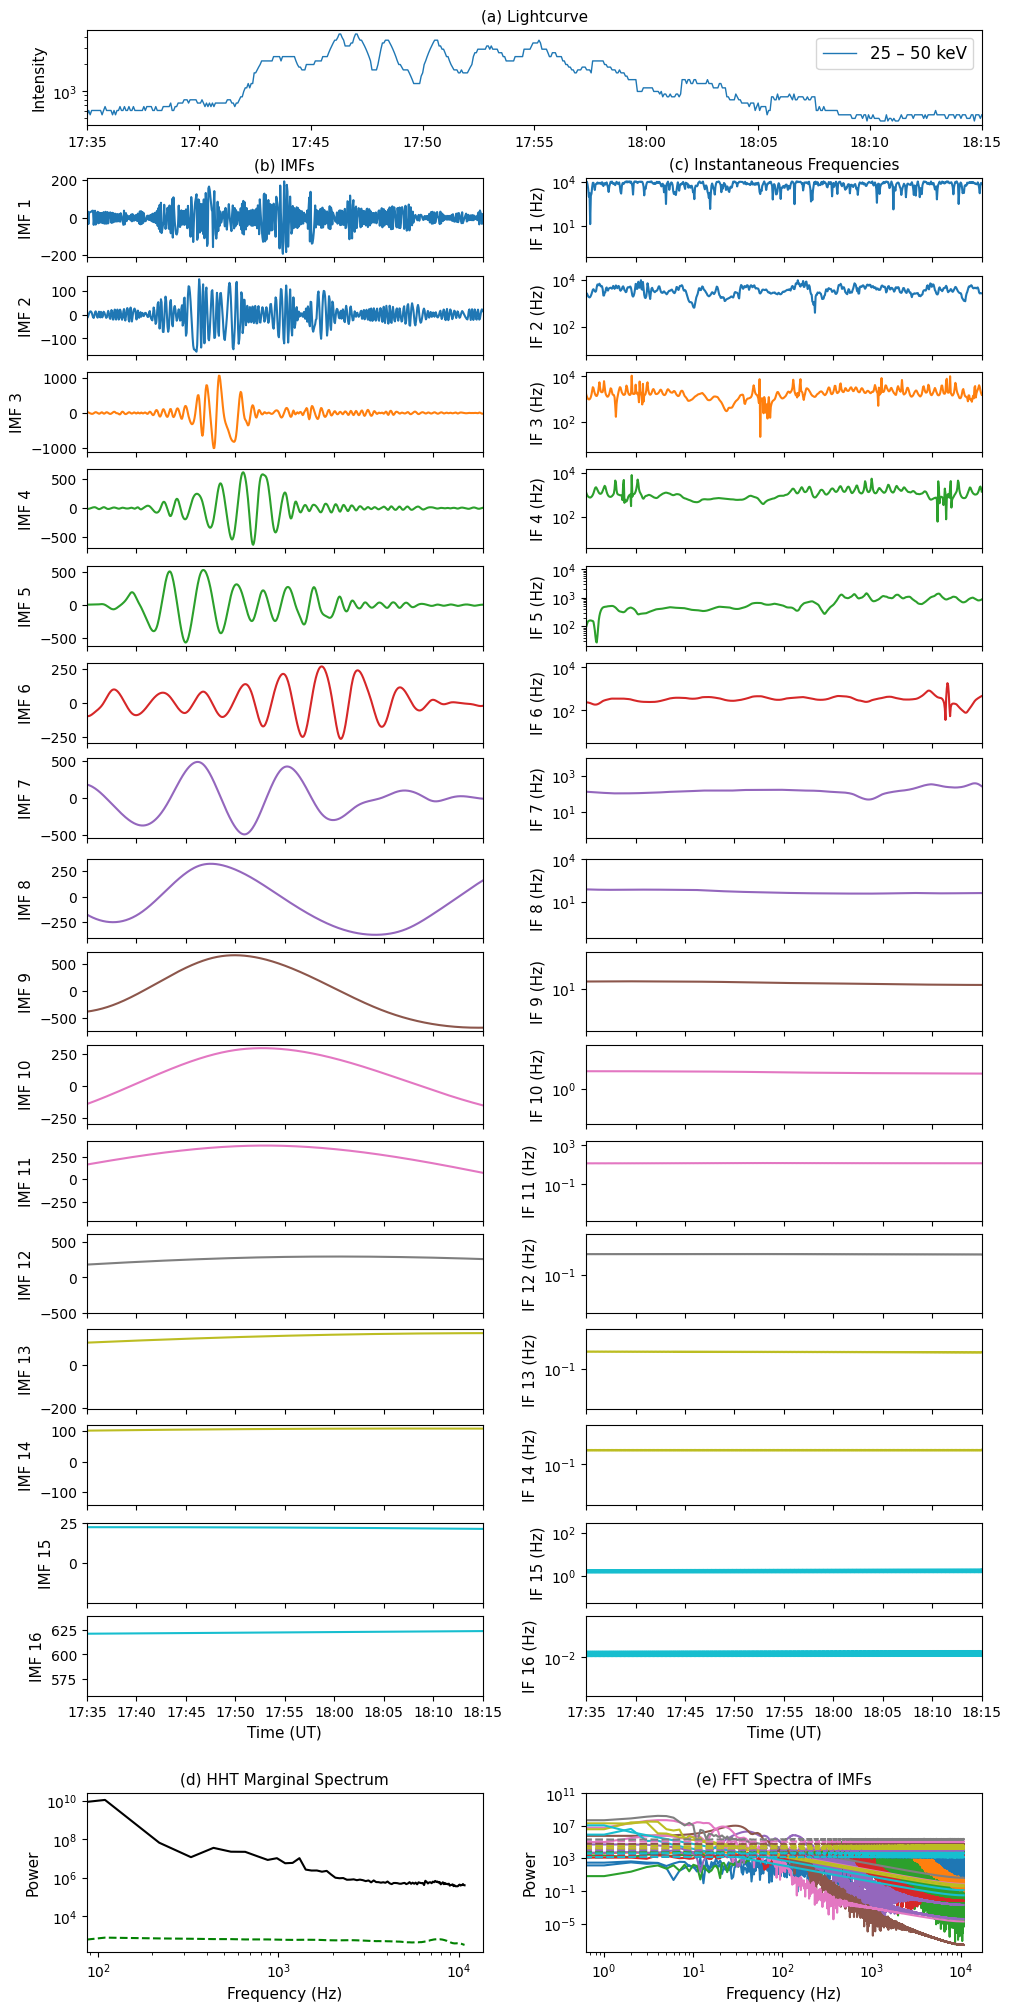

In [108]:
# Global plot settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'figure.titlesize': 12.5,
    'axes.grid': False,
})

colors = plt.cm.tab10(np.linspace(0, 1, len(imfs)))
n_imf = len(imfs)

# Figure + GridSpec
fig = plt.figure(figsize=[10, 20], constrained_layout=True)
gs = gridspec.GridSpec(
    n_imf + 3, 2,
    height_ratios=[1.2] + [1]*n_imf + [0.3, 2],
    figure=fig
)

# -------------------------------------------------
# Top panel: original signal
# -------------------------------------------------
ax_sig = fig.add_subplot(gs[0, :])
ax_sig.plot(time, signal, lw=1, label=label)
ax_sig.set_ylabel('Intensity')
ax_sig.set_yscale('log')
ax_sig.legend()
ax_sig.xaxis_date()
ax_sig.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_sig.set_xlim(time[0], time[-1])
ax_sig.set_title('(a) Lightcurve')
ax_sig.set_xlim(pd.Timestamp(start_time), pd.Timestamp(end_time))

# -------------------------------------------------
# IMF + Instantaneous frequency panels
# -------------------------------------------------
for i, (imf, freq) in enumerate(zip(imfs, instantaneous_frequencies)):
    ax_imf = fig.add_subplot(gs[i + 1, 0])
    ax_if  = fig.add_subplot(gs[i + 1, 1])

    ax_imf.plot(time, imf, color=colors[i], label=f'IMF {i+1}')
    ax_imf.set_ylabel(f'IMF {i+1}')
    ax_imf.xaxis_date()
    ax_imf.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax_imf.set_xlim(pd.Timestamp(start_time), pd.Timestamp(end_time))
    if i < n_imf - 1:
        ax_imf.set_xticklabels([])
    if i == 0:
        ax_imf.set_title('(b) IMFs')
    if i == n_imf - 1:
        ax_imf.set_xlabel('Time (UT)')

    if len(freq) < len(time):
        freq = np.append(freq, freq[-1])

    ax_if.plot(time, freq, color=colors[i], label=f'IF {i+1}')
    ax_if.set_ylabel(f'IF {i+1} (Hz)')
    ax_if.set_yscale('log')
    ax_if.xaxis_date()
    ax_if.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax_if.set_xlim(pd.Timestamp(start_time), pd.Timestamp(end_time))
    if i < n_imf - 1:
        ax_if.set_xticklabels([])
    if i == 0:
        ax_if.set_title('(c) Instantaneous Frequencies')
    if i == n_imf - 1:
        ax_if.set_xlabel('Time (UT)')

# -------------------------------------------------
# Bottom row: HHT + FFT
# -------------------------------------------------
ax_hht = fig.add_subplot(gs[-1, 0])
ax_hht.plot(HHT_freq_bins, HHT_power_spectrum, color='black')
ax_hht.plot(HHT_freq_bins, HHT_significance_level, '--', color='green')
ax_hht.set_title('(d) HHT Marginal Spectrum')
ax_hht.set_xlabel('Frequency (Hz)')
ax_hht.set_ylabel('Power')
ax_hht.set_xscale('log')
ax_hht.set_yscale('log')

ax_fft = fig.add_subplot(gs[-1, 1])
for i, (xf, psd) in enumerate(psd_spectra_fft):
    ax_fft.plot(xf, psd, color=colors[i], label=f'IMF {i+1}')
for i, confidence_level in enumerate(confidence_levels_fft):
    ax_fft.plot(xf, confidence_level, '--', color=colors[i])

ax_fft.set_title('(e) FFT Spectra of IMFs')
ax_fft.set_xlabel('Frequency (Hz)')
ax_fft.set_ylabel('Power')
ax_fft.set_xscale('log')
ax_fft.set_yscale('log')

plt.show()

In [109]:
len(imfs)

16

---
Troupleshooting

In [12]:
[x for x in dir(data[1]) if not x.startswith('_')]

['add_checksum',
 'add_datasum',
 'columns',
 'copy',
 'data',
 'dump',
 'filebytes',
 'fileinfo',
 'from_columns',
 'fromstring',
 'header',
 'is_image',
 'level',
 'load',
 'match_header',
 'name',
 'readfrom',
 'register_hdu',
 'req_cards',
 'run_option',
 'size',
 'unregister_hdu',
 'update',
 'update_header',
 'ver',
 'verify',
 'verify_checksum',
 'verify_datasum',
 'writeto']